# 3.7 "찐" Multi-Agent System (feat. create_react_agent)

- 도구들을 활용하는 에이전트들이 협업하는 과정을 구현합니다

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='gpt-4o',
    temperature=0
)

small_llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0
)

In [3]:
# %pip install --upgrade --quiet  yfinance
# uv로 이미 모두 설치됨

In [4]:
from langgraph.graph import MessagesState
from langgraph.types import Command
from typing import Literal
from langchain_core.messages import HumanMessage
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool

from langgraph.prebuilt import create_react_agent # 생각하는 에이전트 -> 도구를 사용하여 스스로 어떤 도구를 사용할지 판단
from langchain_community.agent_toolkits.polygon.toolkit import PolygonToolkit
from langchain_community.utilities.polygon import PolygonAPIWrapper

# Polygon API를 초기화합니다.
polygon = PolygonAPIWrapper()

# Polygon API로부터 도구 모음을 생성합니다.
toolkit = PolygonToolkit.from_polygon_api_wrapper(polygon)

# 도구들을 가져옵니다.
polygon_tools = toolkit.get_tools()

# 시장 조사 도구 목록을 생성합니다.
market_research_tools = [YahooFinanceNewsTool()] + polygon_tools

# 시장 조사 에이전트를 생성합니다.
market_research_agent = create_react_agent( #사용할 오구를 넘겨 생각하는 에이전트를 생성
    llm, 
    tools=market_research_tools, 
    state_modifier='You are a market researcher. Provide fact only not opinions' # 상황에 맞게 에이전트의 행동을 제어하는 프롬프트로 페르소나를 설정
)

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]: # 시장 조사 에이전트에 대한 노드
    """
    시장 조사 node입니다. 주어진 state를 기반으로 시장 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    # 시장 조사 에이전트를 호출하여 결과를 얻습니다.
    result = market_research_agent.invoke(state)
    
    # 결과 메시지를 업데이트하고 supervisor node로 이동합니다.
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},  # 가장 마지막 메시지를 가져와서 업데이트
        goto='supervisor'
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict: # stock 가격을 가져오는 custom tool, agent name: get_stock_price
    """Given a stock ticker, return the price data for the past month""" # description
    stock_info = yf.download(ticker, period='1mo').to_dict() # download 메서드를 사용하여 1개월 간의 주식 가격 데이터를 가져옴.
    return stock_info # candlestick 데이터 형태로 반환


stock_research_tools = [get_stock_price]
stock_research_agent = create_react_agent(
    llm, tools=stock_research_tools, state_modifier='You are a stock researcher. Provide facts only not opinions'
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]: # get_stcok_price 도구를 사용하는 주식 조사 에이전트에 대한 노드
    """
    주식 조사 node입니다. 주어진 State를 기반으로 주식 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = stock_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [6]:
@tool
def company_research_tool(ticker: str) -> dict: # 회사의 재무 정보와 SEC 보고서를 반환하는 도구, agent name: company_research_tool
    """Given a ticker, return the financial information and SEC filings""" # description
    company_info = yf.Ticker(ticker) # yf.Ticker 객체를 생성하여 주어진 ticker에 대한 회사 정보를 가져옵니다.
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_react_agent(
    llm, tools=company_research_tools, state_modifier='You are a company researcher. Provide facts only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    회사 조사 node입니다. 주어진 State를 기반으로 회사 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = company_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )

In [ ]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template(
    """You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.

Information:
{messages}"""
)

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    """
    분석가 node입니다. 주어진 State를 기반으로 분석가 체인을 호출하고,
    결과 메시지를 반환합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        dict: 분석 결과 메시지를 포함하는 딕셔너리를 반환합니다.
    """
    result = analyst_chain.invoke({'messages': state['messages'][1:]}) # 첫 번째 메시지는 사용자 메시지이므로 제외하고 분석가 체인에 전달

    return {'messages': [result]} # state로 반환

- `supervisor`가 회사의 매니저와 유사한 역할을 하면서, 각 에이전트들의 결과를 종합하여 작업이 끝났는지 판단합니다

In [8]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
options = members + ["FINISH"]


# supervisor node를 위한 시스템 프롬프트. 각 worker의 역할과 다음에 수행할 worker를 결정하는 역할을 명확히 설명.
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]



def supervisor_node(state: MessagesState) -> Command[Literal[*members, "analyst"]]:
    """
    supervisor node입니다. 주어진 State를 기반으로 각 worker의 결과를 종합하고,
    다음에 수행할 worker를 결정합니다. 모든 작업이 완료되면 analyst node로 이동합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: 다음에 수행할 worker 또는 analyst node로 이동하기 위한 명령을 반환합니다.
    """
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = "analyst"

    return Command(goto=goto)

- `node`를 추가하고 `edge`로 연결합니다

In [9]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analyst", analyst_node)

In [10]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()


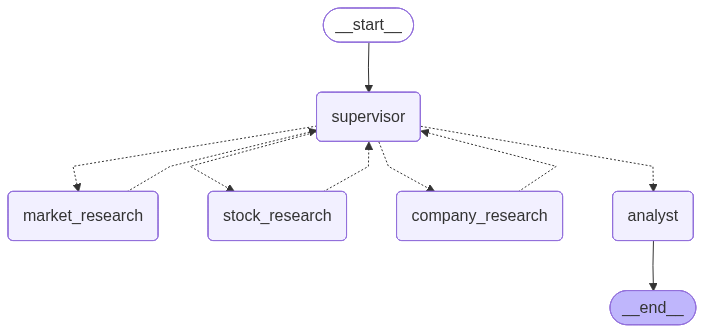

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
for chunk in graph.stream(
    {"messages": [("user", "Would you invest in Snowflake?")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Would you invest in Snowflake?
================================ Human Message =================================
Name: market_research

I cannot provide investment advice or opinions. However, I can provide you with the latest financial data and news about Snowflake (SNOW) to help you make an informed decision. Would you like me to do that?
================================ Human Message =================================
Name: market_research

Here is the latest financial data and news about Snowflake Inc. (SNOW):

### Financial Data
1. **Income Statement (TTM as of October 2025):**
   - Revenues: $4.39 billion
   - Gross Profit: $2.94 billion
   - Operating Income/Loss: -$1.50 billion
   - Net Income/Loss: -$1.35 billion
   - Basic Earnings Per Share: -$4.03

2. **Balance Sheet (as of October 2025):**
   - Total Assets: $8.23 billion
   - Total Liabilities: $6.10 billion
   - Total Equity: $2.13 billion

3

Failed to get ticker 'SNOW' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SNOW']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


================================ Human Message =================================
Name: stock_research

I attempted to retrieve the latest stock price data for Snowflake Inc. (SNOW) for the past month, but it seems there is an issue with accessing the data at the moment. 

For the most accurate and up-to-date stock price information, you may want to check a financial news website or a stock market app. If you have any other questions or need further information, feel free to ask!


429 Client Error: Too Many Requests for url: https://query2.finance.yahoo.com/v10/finance/quoteSummary/SNOW?modules=secFilings&corsDomain=finance.yahoo.com&formatted=false&symbol=SNOW&crumb=Edge%3A+Too+Many+Requests


================================ Human Message =================================
Name: company_research

I attempted to retrieve the latest financial information and SEC filings for Snowflake Inc. (SNOW), but it seems there is an issue with accessing the data at the moment. 

For the most accurate and up-to-date financial information, you may want to check a financial news website or the SEC's EDGAR database. If you have any other questions or need further information, feel free to ask!
================================== Ai Message ==================================

Based on the information provided, here are some key points to consider:

1. **Financial Performance:**
   - Snowflake is currently operating at a loss, with a net income/loss of -$1.35 billion and basic earnings per share of -$4.03.
   - The company has a significant amount of liabilities ($6.10 billion) compared to its equity ($2.13 billion).
   - Despite the losses, Snowflake has a positive net cash flow from operating 